In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Set your working directory inside Google Drive
base_dir = "/content/drive/MyDrive/AI351ProjectTest/04-DataAugmentation/"
os.makedirs(base_dir, exist_ok=True)

print("Project folder:", base_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/AI351ProjectTest/04-DataAugmentation/


In [12]:
import pandas as pd

# Set CSV path (modify filename if needed)
csv_path = os.path.join(base_dir, "Filtered_Dataset.csv")

df = pd.read_csv(csv_path)

print("Loaded dataframe shape:", df.shape)
df.head()

Loaded dataframe shape: (37832, 6)


,text,label,label_desc,translation,MetricX24_Raw,MetricX24_Scaled_BATAYAN
0,i didnt feel humiliated,0,sadness,Hindi ako nadamaang nahihiya.,0.277646,98.889417
1,i can go from feeling so hopeless to so damned...,0,sadness,Maaari akong lumipat mula sa pagiging lubos na...,0.417274,98.330905
2,im grabbing a minute to post i feel greedy wrong,3,anger,"Kukuha ako ng isang minuto para mag-post, para...",0.410044,98.359825
3,i am ever feeling nostalgic about the fireplac...,2,love,Lagi akong nakakaramdam ng pag-nostalya tungko...,0.313250,98.747002
4,i am feeling grouchy,3,anger,Masama ang pakiramdam ko.,0.476642,98.093433


In [13]:
# Count per class
class_counts = df["label_desc"].value_counts()

# Percentage per class
class_percent = df["label_desc"].value_counts(normalize=True) * 100

print("Class distribution (counts):")
display(class_counts)
print("\nClass distribution (%):")
display(class_percent)

Class distribution (counts):


,count
label_desc,
sadness,20070
joy,5362
anxiety,3841
stress,2587
fear,2509
anger,2159
love,1304



Class distribution (%):


,proportion
label_desc,
sadness,53.050328
joy,14.173187
anxiety,10.152781
stress,6.838126
fear,6.631952
anger,5.706809
love,3.446818


In [14]:
import numpy as np

N = 6000  # <-- CHANGE THIS to desired number of samples

# Find the largest class
largest_class = df["label_desc"].value_counts().idxmax()

print("Largest class:", largest_class)

# Split into largest-class and remaining data
df_largest = df[df["label_desc"] == largest_class]
df_other = df[df["label_desc"] != largest_class]

print("Largest class original size:", len(df_largest))

# Randomizer Seed
seed = 397

# Random downsampling
df_largest_down = df_largest.sample(N, random_state=seed)

# Recombine downsampled data
df_downsampled = pd.concat([df_largest_down, df_other], ignore_index=True)

print("New dataframe shape:", df_downsampled.shape)
df_downsampled.head()

Largest class: sadness
Largest class original size: 20070
New dataframe shape: (23762, 6)


,text,label,label_desc,translation,MetricX24_Raw,MetricX24_Scaled_BATAYAN
0,Normally I hate even thinking about this becau...,0,sadness,Karaniwan akong ayaw mag-isip tungkol dito dah...,0.180561,99.277754
1,"You are not alone, trust me. We all face our h...",0,sadness,"Hindi ka nag-iisa, maniwala ka sa akin. Lahat ...",0.221019,99.115925
2,i felt like talking too but i didn t know what...,0,sadness,Gusto kong magsalita rin pero hindi ko alam ku...,0.923421,96.306317
3,My brother is like my best friend. We are clos...,0,sadness,Ang kapatid ko ay parang pinakamahusay kong ka...,-0.688570,100.000000
4,i feel like nobody really care if i m gone eve...,0,sadness,Nararamdaman kong walang tunay na nag-aalala k...,1.094810,95.620761


In [15]:
new_counts = df_downsampled["label_desc"].value_counts()
new_percent = df_downsampled["label_desc"].value_counts(normalize=True) * 100

print("Updated class distribution (counts):")
display(new_counts)
print("\nUpdated class distribution (%):")
display(new_percent)

Updated class distribution (counts):


,count
label_desc,
sadness,6000
joy,5362
anxiety,3841
stress,2587
fear,2509
anger,2159
love,1304



Updated class distribution (%):


,proportion
label_desc,
sadness,25.250400
joy,22.565441
anxiety,16.164464
stress,10.887131
fear,10.558876
anger,9.085936
love,5.487754


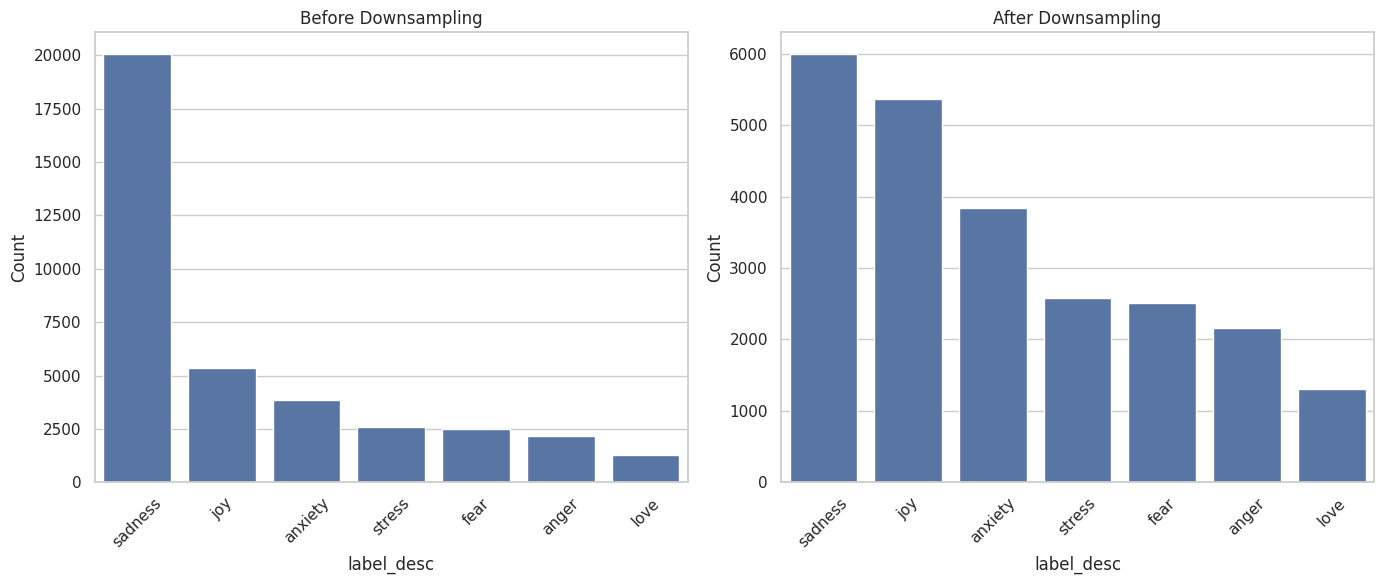

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))

# Before
plt.subplot(1, 2, 1)
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Before Downsampling")
plt.xticks(rotation=45)
plt.ylabel("Count")

# After
plt.subplot(1, 2, 2)
sns.barplot(x=new_counts.index, y=new_counts.values)
plt.title("After Downsampling")
plt.xticks(rotation=45)
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [18]:
output_path = os.path.join(base_dir, "downsampled.csv")
df_downsampled.to_csv(output_path, index=False)

print("Saved downsampled CSV to:", output_path)

Saved downsampled CSV to: /content/drive/MyDrive/AI351ProjectTest/04-DataAugmentation/downsampled.csv
